# 05 — Forecast (SARIMA + Prophet + baselines)

> **Data notice.** Values are real daily revenue multiplied by a single constant scaling factor for privacy. All statistical properties (patterns, breaks, tests, coefficients) are identical to those on the raw data — only the absolute currency level is hidden. Units labeled **LC** (local currency, scaled).

**Task.** Forecast daily revenue for the last ~130 days of the sample (2021-01-01 → 2021-05-10) using models trained on data through 2020-12-31. Compare seven candidate models and pick a winner based on out-of-sample error.

| # | Model | Purpose |
|---|---|---|
| 1 | Seasonal-naive (lag 7) | Baseline: revenue on day d = revenue on day d − 7 |
| 2 | Last-value (lag 1) | Baseline: revenue on day d = revenue on day d − 1 |
| 3 | SARIMA — full history | Regime-blind, uses all training data |
| 4 | SARIMA — post-COVID only | Regime-aware SARIMA variant |
| 5 | Prophet — variant A | With H1 COVID changepoint (2020-03-23) |
| 6 | Prophet — variant B | With H2 changepoints (four-regime structure) |
| 7 | Prophet — variant C | Default auto-detected changepoints (no priors) |

**Metrics reported per model:** MAE, MAPE, RMSE.

**Split rule.** Chronological only — no shuffling, no k-fold. Time series test data must come chronologically after training data or the model leaks the future into training.

**Approach:** data prep with daily-frequency index → chronological split → two baselines → metrics helper → SARIMA (full and post-COVID) → three Prophet variants (single COVID break, H2 breaks, default auto-detection) → fair comparison table + forecast plot + verdict.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').disabled = True
logging.getLogger('prophet').setLevel(logging.ERROR)


plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110

## Load data and split into train / test

**Key design choice — daily-frequency index.** Unlike previous notebooks, the forecasting models here need an *explicit daily frequency* even on days with no data. We use `.asfreq('D')` which fills missing days with NaN. Both the baselines and SARIMA can handle NaN in the training series (SARIMA via state-space missing-data handling; the baselines produce NaN forecasts on days whose lag reference is missing, which we'll leave visible for honesty rather than impute).

**Cut point:** 2020-12-31 / 2021-01-01. Train covers 2019-12-15 → 2020-12-31; test covers 2021-01-01 → 2021-05-10 (~130 days).


In [2]:
df = pd.read_csv('../data/daily_sales_final.csv', parse_dates=['date'])
df = df.set_index('date').sort_index().asfreq('D')
y = df['revenue_scaled']

TRAIN_END = '2020-12-31'
TEST_START = '2021-01-01'

train = y[:TRAIN_END]
test = y[TEST_START:]

print(f'Train: {train.index.min().date()} to {train.index.max().date()} '
      f'({len(train)} days, {train.notna().sum()} non-missing)')
print(f'Test:  {test.index.min().date()} to {test.index.max().date()} '
      f'({len(test)} days, {test.notna().sum()} non-missing)')

Train: 2019-12-15 to 2020-12-31 (383 days, 348 non-missing)
Test:  2021-01-01 to 2021-05-10 (130 days, 122 non-missing)


## Baseline 1 — seasonal-naive (lag 7)

In [3]:
fcst_naive = y.shift(7)[TEST_START:'2021-05-10']
print(fcst_naive.head(10))
print(test.head(10))

date
2021-01-01          NaN
2021-01-02          NaN
2021-01-03          NaN
2021-01-04          NaN
2021-01-05    104511.15
2021-01-06    101984.05
2021-01-07    114342.61
2021-01-08     83013.50
2021-01-09    112140.92
2021-01-10    184443.67
Freq: D, Name: revenue_scaled, dtype: float64
date
2021-01-01     83013.50
2021-01-02    112140.92
2021-01-03    184443.67
2021-01-04    112196.31
2021-01-05    106795.93
2021-01-06    134663.26
2021-01-07    100807.05
2021-01-08     97206.80
2021-01-09    124277.92
2021-01-10    109392.26
Freq: D, Name: revenue_scaled, dtype: float64


The last-value baseline predicts revenue on day *d* as the revenue on day *d − 1*. It's the weakest possible baseline for a series with weekly seasonality — it systematically misses the weekly pattern. Its role is to establish a sanity-check floor, showing that even the simplest lag structure isn't enough.

In [4]:
fcst_lastval = y.shift(1)[TEST_START:'2021-05-10']

## Evaluation metrics

In [5]:
def evaluate(name, fcst, actual):
    combined = pd.concat(
        [fcst.rename('fcst'), actual.rename('actual')],
        axis=1
    ).dropna()
    err = combined['actual'] - combined['fcst']
    mae = err.abs().mean()
    mape = (err.abs() / combined['actual'].abs()).mean() * 100
    rmse = np.sqrt((err ** 2).mean())
    return {'model': name, 'n': len(combined),
            'MAE': mae, 'MAPE': mape, 'RMSE': rmse}

def print_results(results):
    df = pd.DataFrame(results).copy()
    df['MAE']  = df['MAE'].map(lambda x: f'{x:,.0f}')
    df['RMSE'] = df['RMSE'].map(lambda x: f'{x:,.0f}')
    df['MAPE'] = df['MAPE'].map(lambda x: f'{x:.2f}%')
    print(df.to_string(index=False))

results = []
results.append(evaluate('seasonal-naive', fcst_naive, test))
results.append(evaluate('last-value', fcst_lastval, test))

print_results(results)

         model   n    MAE   MAPE   RMSE
seasonal-naive 110 14,506 13.23% 19,622
    last-value 120 19,099 17.83% 24,117


The results show that seasonal-naive at MAE 14.5k / MAPE 13.2% beats last-value at 19.1k / 17.8% on all three metrics. This is expected: the weekend refinement study (H4a) confirmed the concentrated WE1 depression, and seasonal-naive captures this weekly cycle by using each day's value from seven days prior. Last-value, by contrast, uses yesterday's value and cannot carry the weekly cycle forward — it systematically over-predicts on WE1 days (whose immediate predecessor is a normal business day) and under-predicts on the business day following WE1.

The seasonal-naive metrics — MAE = 14.5k, MAPE = 13.2%, RMSE = 19.6k — define the threshold any more sophisticated model must beat to justify its complexity. In what follows we fit three sophisticated models: SARIMA on the full training history, SARIMA on the post-COVID subset only (regime-aware), and Prophet with a 2020-03-23 changepoint. If none of them beats seasonal-naive, then the simple lag-7 rule is the correct production choice.

In [6]:
model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
res = model.fit(disp=False)          # disp=False silences the optimizer chatter
forecast_sarima_full = res.forecast(steps=len(test))
results = [r for r in results if r['model'] != 'SARIMA FULL']
results.append(evaluate('SARIMA FULL', forecast_sarima_full, test))
print_results(results)

         model   n    MAE   MAPE   RMSE
seasonal-naive 110 14,506 13.23% 19,622
    last-value 120 19,099 17.83% 24,117
   SARIMA FULL 122 19,263 16.68% 24,216


The table above shows that SARIMA FULL loses on all metrics to seasonal-naive: MAE 19.3k vs 14.5k, MAPE 16.7% vs 13.2%, RMSE 24.2k vs 19.6k. This is likely a consequence of non-homogeneity in the training set — H2 (notebook 02) established four distinct regimes: pre-COVID, acute crash, partial rebound, and the start of terminal decline. A single SARIMA fits one set of (p, d, q)(P, D, Q, 7) parameters to all of them and settles on "average" dynamics that don't match any particular regime, especially not the terminal-decline regime that dominates the test set. Compounding this, a small SARIMA forecasting 130 steps ahead converges toward a mean-reverting steady state; if that steady state sits above the true terminal-decline level (because it was averaged with the higher pre-COVID data), every forecast beyond a few days ahead will overshoot. This motivates the next section: training SARIMA on the post-COVID subset only, whose dynamics actually resemble the test regime.


## Post-COVID SARIMA

In [7]:
model = SARIMAX(train['2020-03-26':], order=(1,1,1), seasonal_order=(1,1,1,7))
res = model.fit(disp=False)
fcst_sarima_post_covid = res.forecast(steps=len(test))
results = [r for r in results if r['model'] != 'SARIMA post-COVID']
results.append(evaluate('SARIMA post-COVID', fcst_sarima_post_covid, test))
print_results(results)

            model   n    MAE   MAPE   RMSE
   seasonal-naive 110 14,506 13.23% 19,622
       last-value 120 19,099 17.83% 24,117
      SARIMA FULL 122 19,263 16.68% 24,216
SARIMA post-COVID 122 16,698 14.38% 21,644


The table above shows that regime-aware training helps SARIMA (~13%): Post-COVID SARIMA beats full-history SARIMA on every metric (MAE 16.7k vs 19.3k). However, even with this help, post-COVID SARIMA failed to beat seasonal-naive. This may be the result of many factors. Post-COVID is not one regime as confirmed by H2: the "post-COVID" training window still contains acute crash + partial rebound + start-of-terminal-decline. The test set is entirely in terminal decline. So SARIMA is still averaging across mismatched dynamics, just with a smaller mismatch than before. On top of that the long-horizon mean reversion still applies. 130-step-ahead forecasts converge on a steady state that doesn't track terminal-decline's drift. 

## PROPHET — COVID changepoint only

In [8]:
# Reshape training data to Prophet's expected format
train_df = train.reset_index().rename(columns={'date': 'ds', 'revenue_scaled': 'y'})
train_df = train_df.dropna()

# Fit
m = Prophet(
    changepoints=['2020-03-23'],
    weekly_seasonality=True,     # captures the weekly cycle
    yearly_seasonality=False,    # only 15 months of data, not enough for annual pattern
    daily_seasonality=False,     # no intraday info
)
m.fit(train_df)

# Forecast 130 days ahead
future = m.make_future_dataframe(periods=len(test))
forecast = m.predict(future)
# forecast has columns: ds, yhat, yhat_lower, yhat_upper, plus components

# Extract just the test window forecast
fcst_prophet_A = forecast.set_index('ds').loc[test.index, 'yhat']
results = [r for r in results if r['model'] != 'PROPHET-covid-change-point']
results.append(evaluate('PROPHET-covid-change-point', fcst_prophet_A, test))
print_results(results)

                     model   n    MAE   MAPE   RMSE
            seasonal-naive 110 14,506 13.23% 19,622
                last-value 120 19,099 17.83% 24,117
               SARIMA FULL 122 19,263 16.68% 24,216
         SARIMA post-COVID 122 16,698 14.38% 21,644
PROPHET-covid-change-point 122 23,709 22.85% 26,478


Prophet with only the H1 changepoint underperforms both baselines. This isn't a failure of Prophet — it's a demonstration that a single-break specification is insufficient for a series with multiple sequential regime changes. The next variant tests whether providing the full H2 regime structure rescues the model.

## PROPHET — H2 changepoints

In [9]:
m = Prophet(
    changepoints=['2020-03-26', '2020-05-27', '2020-12-02'],
    weekly_seasonality=True,     
    yearly_seasonality=False,    
    daily_seasonality=False,    
)
m.fit(train_df)
future = m.make_future_dataframe(periods=len(test))
forecast = m.predict(future)
fcst_prophet_B = forecast.set_index('ds').loc[test.index, 'yhat']
results = [r for r in results if r['model'] != 'PROPHET-H2-change-points']
results.append(evaluate('PROPHET-H2-change-points', fcst_prophet_B, test))
print_results(results)



                     model   n    MAE   MAPE   RMSE
            seasonal-naive 110 14,506 13.23% 19,622
                last-value 120 19,099 17.83% 24,117
               SARIMA FULL 122 19,263 16.68% 24,216
         SARIMA post-COVID 122 16,698 14.38% 21,644
PROPHET-covid-change-point 122 23,709 22.85% 26,478
  PROPHET-H2-change-points 122 24,553 23.67% 27,333


Variant B did not rescue Prophet — in fact, it performed slightly worse than variant A on every metric. Adding two more changepoints gave the model more flexibility to fit noisy slopes in short in-regime windows (the terminal-decline changepoint at 2020-12-02 has only ~30 days of post-changepoint training data), and those slopes then extrapolated linearly across a 130-day horizon, compounding the error. Since injecting our H1 and H2 priors both hurt Prophet, the honest next test is whether letting Prophet find its own changepoints does better. Variant C therefore removes the changepoints= argument entirely and relies on Prophet's default auto-detection.

## PROPHET — default

In [10]:
m = Prophet(
    weekly_seasonality=True,     
    yearly_seasonality=False,    
    daily_seasonality=False,    
)
m.fit(train_df)
future = m.make_future_dataframe(periods=len(test))
forecast = m.predict(future)
fcst_prophet_default = forecast.set_index('ds').loc[test.index, 'yhat']
results = [r for r in results if r['model'] != 'PROPHET']
results.append(evaluate('PROPHET default', fcst_prophet_default, test))
print_results(results)

                     model   n    MAE   MAPE   RMSE
            seasonal-naive 110 14,506 13.23% 19,622
                last-value 120 19,099 17.83% 24,117
               SARIMA FULL 122 19,263 16.68% 24,216
         SARIMA post-COVID 122 16,698 14.38% 21,644
PROPHET-covid-change-point 122 23,709 22.85% 26,478
  PROPHET-H2-change-points 122 24,553 23.67% 27,333
           PROPHET default 122 13,281 12.49% 16,566


## Fair comparison — common evaluation window

In [11]:

forecasts = {
    'seasonal-naive':          fcst_naive,
    'last-value':              fcst_lastval,
    'SARIMA FULL':             forecast_sarima_full,
    'SARIMA post-COVID':       fcst_sarima_post_covid,
    'Prophet A (COVID break)': fcst_prophet_A,          # optional — comment if not defined
    'Prophet B (H2 breaks)':   fcst_prophet_B,          # optional — comment if not defined
    'Prophet default':         fcst_prophet_default,
}

# Common non-NaN index across the test set AND every forecast
common_idx = test.dropna().index
for f in forecasts.values():
    common_idx = common_idx.intersection(f.dropna().index)

print(f'Common evaluation window: {len(common_idx)} days '
      f'({common_idx.min().date()} → {common_idx.max().date()})')

fair_rows = []
actual_common = test.loc[common_idx]
for name, fcst in forecasts.items():
    aligned = fcst.loc[common_idx]
    err = actual_common - aligned
    fair_rows.append({
        'model': name,
        'n': len(common_idx),
        'MAE':  err.abs().mean(),
        'MAPE': (err.abs() / actual_common.abs()).mean() * 100,
        'RMSE': np.sqrt((err ** 2).mean()),
    })

fair_df = pd.DataFrame(fair_rows).sort_values('MAE').reset_index(drop=True)
fair_df['MAE']  = fair_df['MAE'].map(lambda x: f'{x:,.0f}')
fair_df['MAPE'] = fair_df['MAPE'].map(lambda x: f'{x:.2f}%')
fair_df['RMSE'] = fair_df['RMSE'].map(lambda x: f'{x:,.0f}')
print(fair_df.to_string(index=False))

Common evaluation window: 109 days (2021-01-05 → 2021-05-10)
                  model   n    MAE   MAPE   RMSE
        Prophet default 109 12,991 12.46% 16,018
         seasonal-naive 109 14,212 13.07% 19,201
      SARIMA post-COVID 109 16,669 14.61% 20,964
             last-value 109 18,044 17.00% 22,185
            SARIMA FULL 109 19,299 16.97% 23,698
Prophet A (COVID break) 109 23,818 23.19% 26,680
  Prophet B (H2 breaks) 109 24,695 24.04% 27,574


The table above shows that Prophet default beats seasonal-naive by 8.6% on MAE, 0.61 pp on MAPE, and 16.6% on RMSE.
All rankings preserved from the unfair-window tables — no model's position changed when evaluated on identical days. That's evidence the story wasn't an artifact of NaN-days handling.
All models' errors dropped slightly on the fair window. The ~13 days dropped from the intersection were probably harder-than-average days that seasonal-naive was missing anyway.

## Forecast plot — top models vs actual

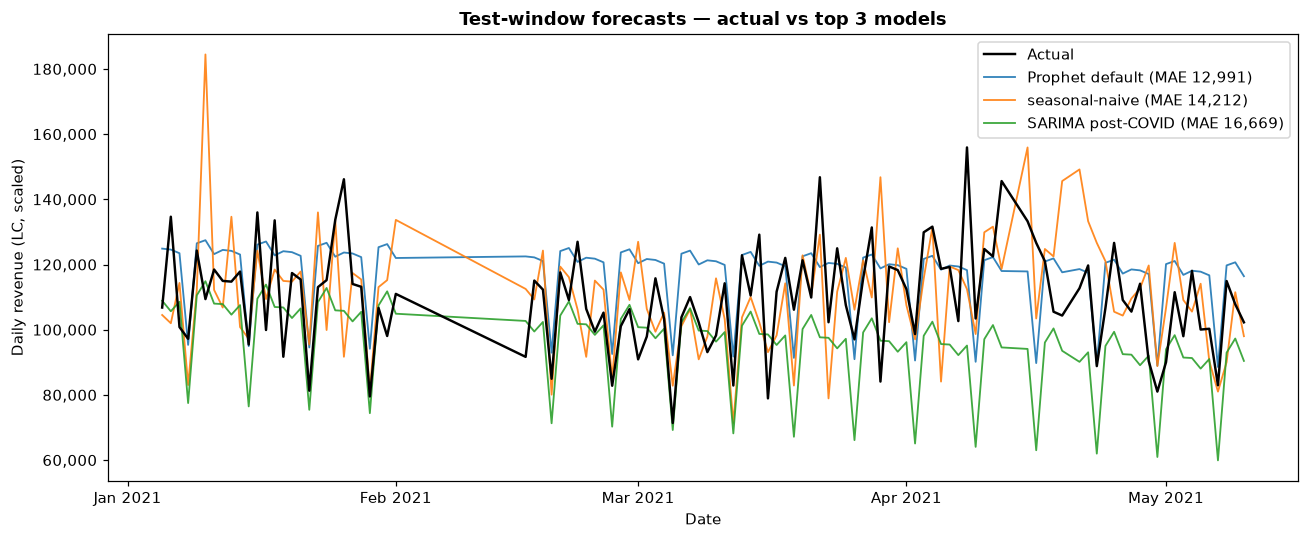

In [12]:
# Pick top 3 by MAE from the fair comparison
top3_names = fair_df.head(3)['model'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))

# Actual values
ax.plot(actual_common.index, actual_common.values,
        color='black', linewidth=1.6, label='Actual', zorder=5)

# Top 3 forecasts
colors = ['tab:blue', 'tab:orange', 'tab:green']
for name, c in zip(top3_names, colors):
    fcst = forecasts[name].loc[common_idx]
    mae_str = fair_df.set_index('model').loc[name, 'MAE']
    ax.plot(fcst.index, fcst.values, color=c, linewidth=1.2, alpha=0.9,
            label=f'{name} (MAE {mae_str})')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set(xlabel='Date', ylabel='Daily revenue (LC, scaled)',
       title='Test-window forecasts — actual vs top 3 models')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../charts/h5_forecast_top3.png', dpi=120, bbox_inches='tight')
plt.show()

The plot shows that Prophet default, unlike seasonal-naive and SARIMA in this comparison, doesn't try to capture the sharp WE1 depressions or daily volatility. Its win comes from something different: it never makes a large error. On business days, Prophet is within ~10k of the actual (small errors); on WE1 days, Prophet misses by 40-50k (larger errors, but only ~2 of every 7 days). Average error stays around 13k because business days dominate the count. This is why RMSE — which penalizes big errors quadratically — widens Prophet's advantage over MAE.

The second visible feature is seasonal-naive's occasional large spikes. On January 10, for example, seasonal-naive copied a peak from the previous week directly into its forecast, missing by ~70k on that single day. This outlier-propagation pattern repeats a few times across the test window and is the mechanism behind seasonal-naive's inflated RMSE.

Finally, the SARIMA line starts near 110k in January but drifts steadily down to ~90-100k by May — a slow convergence toward the model's steady-state mean, which was pulled downward by the terminal-decline tail of the training data. Even though SARIMA captures the sharp WE1 dips more accurately than Prophet, the systematic downward bias accumulates over the 130-day horizon and costs it the comparison.

## Verdict

The tests show that Prophet default wins, beating seasonal-naive by ~8.6% on MAE (12,991 vs 14,212 LC), 0.61 percentage points on MAPE (12.46% vs 13.07%), and ~16.6% on RMSE (16,018 vs 19,201 LC). The RMSE gap exceeds the MAE gap, reflecting Prophet's edge in avoiding large errors — its smoothed weekly component absorbs anomalies that seasonal-naive propagates directly.

Data-driven changepoints beat expert-specified ones. Both Prophet variants that used explicit H1 / H2 domain knowledge underperformed the naive baselines. When we removed the changepoint specification and let Prophet auto-detect, it won overall. Mechanism: more candidate changepoints + L1 shrinkage let Prophet fit local structure; forcing it to only 1 or 3 pre-specified changepoints gave it too little flexibility and rewarded poorly-estimated in-regime slopes.

Regime-aware SARIMA (post-COVID) improved on SARIMA-full by ~13% but still lost to seasonal-naive by ~17% on MAE (16,669 vs 14,212 LC). Reason: even the post-COVID subset spans three sub-regimes; SARIMA's multi-step-ahead forecast drifts toward a steady-state mean pulled down by the terminal-decline tail of the training data; and the weekly cycle is harder to capture via AR/MA than via direct lag copy.

**Methodological caveat — multiple comparisons.** The winner's out-of-sample MAE is a mildly biased estimate because it is the best of seven models on a single hold-out window. Production forecasting would use walk-forward evaluation and champion-challenger rotation on rolling test windows to reduce this bias. Reported metrics should be read as relative model comparisons rather than absolute error certificates.